[2026-07-17 Fiddler](https://thefiddler.substack.com/p/can-you-win-the-world-cup)
====================

Fiddler
-------
If the strategy is to allocate $E$ to the semis, the probability of making the
finals is $E$, with $1-E$ remaining.

On the other side of the bracket, the probability distribution of each semifinalist
is $1$.  The probability distribution of the energy used by the winner of the other
side of the bracket is $2E$.

In [1]:
E, E1, E2 = var("E,E1,E2")
integral(1, E1, 0, E) + integral(1, E2, 0, E)

2*E

The probability distribution of the remaining energy of the finals opponent is
$2-2E$, so the probability that the finals opponent has less than $1-E$
remaining is $1-E^2$, so the probability of winning the championship is $E-E^3$,
which has a maximum at $E = 1/\sqrt3 \approx 0.57735$, and the maximum probability
is $2/\sqrt{27} \approx 38.490\%$.

In [2]:
integral(2-2*E1,E1,0,1-E)

-E^2 + 1

### Simulations
Running [simulations](20260717.go) agree, giving the maximum probability
of approximately 38.5% when $E$ is approximately 0.58.

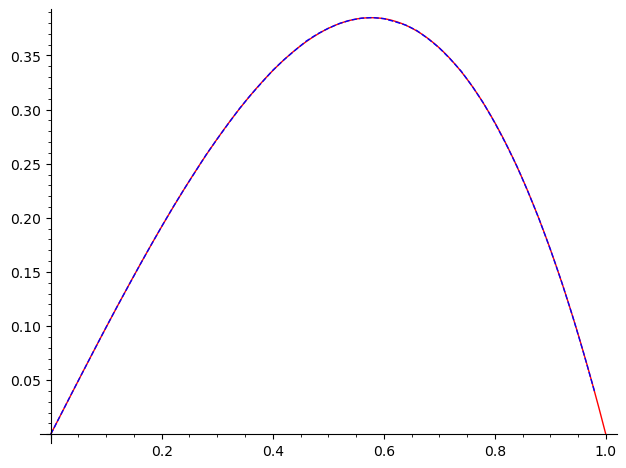

In [3]:
plot(E-E^3, E, 0, 1, color="red") + line([
(0.000000,0.000000),(0.020000,0.019952),(0.040000,0.039998),(0.060000,0.059682),(0.080000,0.079486),(0.100000,0.099090),(0.120000,0.118308),(0.140000,0.137088),(0.160000,0.155845),(0.180000,0.174154),(0.200000,0.192044),(0.220000,0.209554),(0.240000,0.226217),(0.260000,0.242204),(0.280000,0.258308),(0.300000,0.272865),(0.320000,0.287056),(0.340000,0.300885),(0.360000,0.313330),(0.380000,0.324830),(0.400000,0.336235),(0.420000,0.345918),(0.440000,0.354685),(0.460000,0.363134),(0.480000,0.369740),(0.500000,0.375081),(0.520000,0.379509),(0.540000,0.382646),(0.560000,0.384446),(0.580000,0.385003),(0.600000,0.384026),(0.620000,0.381230),(0.640000,0.377958),(0.660000,0.372813),(0.680000,0.365383),(0.700000,0.356976),(0.720000,0.346575),(0.740000,0.335121),(0.760000,0.321097),(0.780000,0.305573),(0.800000,0.287791),(0.820000,0.268412),(0.840000,0.247476),(0.860000,0.223884),(0.880000,0.198592),(0.900000,0.170981),(0.920000,0.141400),(0.940000,0.109362),(0.960000,0.075136),(0.980000,0.038972)
], linestyle="dashed")

Extra credit
------------
If I allocate $Q$ to the quarterfinals, my probability of advancing is $Q$, with $1-Q$
energy remaining.

The probability distribution the remaining energy of my opponent in the semis is
$2-2E$, so the probability distribution of my opponent's allocation to the semis is
$3E^2-6E+3$.

In [4]:
integral(2-2*E1, E1, E, 1)/integral(integral(2-2*E1, E1, E, 1), E, 0, 1)

3*E^2 - 6*E + 3

So if I allocate $S$ to the semis, my probability of advancing is
is $S^3-3S^2+3S$, with $1-Q-S$ energy remaining.

In [5]:
S = var("S")
integral(3*E^2 - 6*E + 3, E, 0, S)

S^3 - 3*S^2 + 3*S

On the other side of the bracket, the probability distribution of the remaining
energy of the winner is

In [6]:
integral((2-2*E1)
         *integral(3*E2^2-6*E2+3, E2, 0, E1-E),
         E1, E, 1)/integral(integral((2-2*E1)
                            *integral(3*E2^2-6*E2+3, E2, 0, E1-E),
                            E1, E, 1), E, 0, 1)

-3/5*E^5 + 6*E^2 - 9*E + 18/5

So my probability of winning the finals is

In [7]:
P(Q,S) = Q*(S^3-3*S^2+3*S)*integral(-3/5*E^5+6*E^2-9*E+18/5,E,0,1-Q-S)
P

(Q, S) |--> -1/10*(Q^6 + 6*(Q - 1)*S^5 + S^6 - 6*Q^5 + 15*(Q^2 - 2*Q + 1)*S^4 + 15*Q^4 + 20*(Q^3 - 3*Q^2 + 3*Q)*S^3 + 15*(Q^4 - 4*Q^3 + 6*Q^2)*S^2 + 6*(Q^5 - 5*Q^4 + 10*Q^3)*S - 10)*(S^3 - 3*S^2 + 3*S)*Q

In [8]:
def g(Q,S):
    if Q+S >= 1:
        return 0
    #return P(Q,S)
    return -1/10*(Q^6 + 6*(Q - 1)*S^5 + S^6 - 6*Q^5 + 15*(Q^2 - 2*Q + 1)*S^4 + 15*Q^4 + 20*(Q^3 - 3*Q^2 + 3*Q)*S^3 + 15*(Q^4 - 4*Q^3 + 6*Q^2)*S^2 + 6*(Q^5 - 5*Q^4 + 10*Q^3)*S - 10)*(S^3 - 3*S^2 + 3*S)*Q

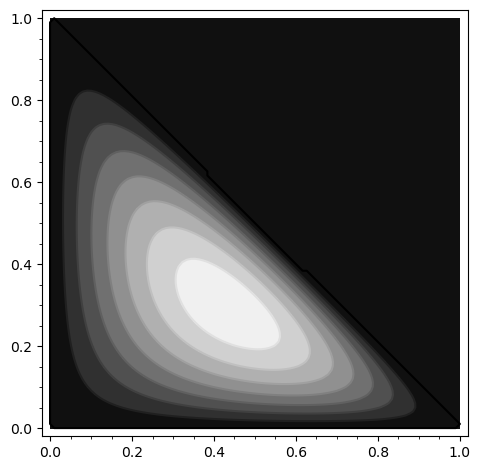

In [9]:
contour_plot(g,(0,1),(0,1))

It looks like the maximum is where the quarterfinal allocation is
approximately 45% and the semifinal allocation is approximately 30%.

Numerically, it looks like the maximum probability is approximately 19.309%,
where the quarterfinal allocation is approximately 43.309% and the
semifinal allocation is approximately 29.385%.

In [10]:
minimize(-P,(0.45,0.3))

(0.43309365777368636, 0.293851189710256)

In [11]:
P(0.43309365777368636, 0.293851189710256)

0.193092769712798

### Simulations
Running [simulations](20260717.go) does not agree, giving a maximum probability
of approximately 28% with an approximately 53% allocation in the quarterfinals
and an approximately 23% allocation in the semifinals, so either my calculation
has mistakes, my simulation has mistakes, or both have mistakes.

In [12]:
def f(x,y):
    data = [[0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000],
[0.000000,0.004650,0.007455,0.009729,0.011699,0.013324,0.014741,0.015911,0.016939,0.018127,0.018592,0.019564,0.020189,0.020509,0.021115,0.021425,0.021817,0.022284,0.021708,0.022170,0.022093,0.021936,0.021896,0.021638,0.021332,0.021035,0.020785,0.019960,0.019336,0.018659,0.017535,0.016735,0.015418,0.014071,0.012598,0.010422,0.008493,0.006226,0.003500,0],
[0.000000,0.009413,0.015123,0.019639,0.023366,0.027155,0.029635,0.031955,0.034259,0.036120,0.037704,0.039183,0.040291,0.040896,0.041629,0.042479,0.043117,0.043615,0.043844,0.043554,0.044182,0.043144,0.042467,0.042384,0.042000,0.040826,0.039705,0.038338,0.036876,0.034876,0.032725,0.030443,0.027864,0.024844,0.021273,0.017331,0.012710,0.006916,0,0],
[0.000000,0.013830,0.022469,0.029641,0.035206,0.040408,0.044470,0.047660,0.051111,0.054062,0.056203,0.058321,0.059511,0.061475,0.062573,0.063692,0.064573,0.064376,0.065275,0.065559,0.064136,0.064415,0.063405,0.062251,0.060539,0.058897,0.057822,0.055200,0.052135,0.049557,0.045729,0.041536,0.036595,0.032214,0.025746,0.018956,0.010531,0,0,0],
[0.000000,0.018235,0.030299,0.039277,0.047219,0.053318,0.058947,0.063449,0.068266,0.071542,0.074177,0.077384,0.079102,0.081427,0.082893,0.084171,0.084150,0.084936,0.085209,0.085676,0.084657,0.083301,0.083039,0.080610,0.078681,0.075630,0.072345,0.069843,0.065595,0.060707,0.055588,0.049458,0.042585,0.034684,0.025210,0.013891,0,0,0,0],
[0.000000,0.023139,0.037558,0.048953,0.058611,0.066646,0.074001,0.079050,0.084940,0.088855,0.093996,0.096097,0.099073,0.101525,0.102307,0.104166,0.104914,0.104680,0.105612,0.104587,0.103864,0.102676,0.099645,0.097206,0.094484,0.091206,0.086441,0.082034,0.075719,0.069281,0.061292,0.052911,0.043150,0.031083,0.017405,0,0,0,0,0],
[0.000000,0.027692,0.044875,0.059119,0.070498,0.079677,0.088193,0.095198,0.101169,0.106490,0.110495,0.115540,0.117500,0.119805,0.122666,0.123466,0.124049,0.123941,0.124029,0.123008,0.121271,0.119014,0.116961,0.113073,0.108747,0.103058,0.097764,0.090813,0.083490,0.073883,0.063823,0.051738,0.037380,0.020820,0,0,0,0,0,0],
[0.000000,0.032476,0.052366,0.069169,0.081568,0.093256,0.102524,0.111143,0.117193,0.123155,0.128870,0.133024,0.135955,0.139081,0.140324,0.142530,0.143285,0.141923,0.142278,0.139435,0.138033,0.133584,0.130580,0.126053,0.120093,0.113341,0.105589,0.096494,0.085644,0.073934,0.060480,0.044319,0.024118,0,0,0,0,0,0,0],
[0.000000,0.036991,0.060119,0.078055,0.093714,0.105427,0.116959,0.126242,0.133321,0.140362,0.146086,0.150850,0.153875,0.157149,0.158961,0.160378,0.160174,0.160170,0.157761,0.155676,0.152527,0.148448,0.143107,0.135731,0.128507,0.119831,0.109877,0.098015,0.084210,0.068113,0.050051,0.027461,0,0,0,0,0,0,0,0],
[0.000000,0.040952,0.067831,0.088355,0.105155,0.119438,0.130639,0.141467,0.149994,0.156828,0.163054,0.167841,0.170959,0.174234,0.175644,0.176572,0.176042,0.175151,0.172709,0.168295,0.165169,0.159614,0.153041,0.143806,0.133786,0.123125,0.110187,0.094754,0.076851,0.055939,0.030940,0,0,0,0,0,0,0,0,0],
[0.000000,0.045744,0.074940,0.097601,0.116351,0.131337,0.144816,0.156439,0.164762,0.172249,0.179456,0.184751,0.187701,0.190215,0.192361,0.192632,0.191575,0.189166,0.185387,0.180891,0.175268,0.167989,0.158445,0.147977,0.135502,0.120652,0.105165,0.085249,0.062139,0.034228,0,0,0,0,0,0,0,0,0,0],
[0.000000,0.050582,0.082086,0.106591,0.126689,0.144815,0.158395,0.170322,0.179465,0.188222,0.194999,0.199701,0.203997,0.205707,0.206286,0.206819,0.204979,0.201383,0.196715,0.190367,0.183071,0.174034,0.162000,0.149365,0.133144,0.114269,0.092547,0.067834,0.038148,0,0,0,0,0,0,0,0,0,0,0],
[0.000000,0.054946,0.089613,0.115835,0.138439,0.156592,0.171538,0.183311,0.194642,0.202765,0.210334,0.214751,0.218774,0.220427,0.220199,0.218931,0.216103,0.211257,0.204937,0.197681,0.186936,0.175492,0.161444,0.144395,0.123448,0.101071,0.074223,0.041074,0,0,0,0,0,0,0,0,0,0,0,0],
[0.000000,0.059210,0.096485,0.125057,0.148458,0.168326,0.185066,0.197854,0.208800,0.216944,0.223690,0.228181,0.231205,0.233714,0.232167,0.229359,0.224836,0.219536,0.211732,0.201181,0.188760,0.172851,0.154681,0.134261,0.108442,0.079465,0.044096,0,0,0,0,0,0,0,0,0,0,0,0,0],
[0.000000,0.063490,0.103360,0.134509,0.158859,0.179880,0.197419,0.209976,0.221263,0.229777,0.236256,0.240604,0.244159,0.243762,0.241517,0.238162,0.231979,0.224254,0.213755,0.199893,0.184976,0.165086,0.143024,0.116669,0.084944,0.047777,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
[0.000000,0.068289,0.110202,0.142734,0.169009,0.189711,0.208571,0.222881,0.232690,0.242039,0.248921,0.252472,0.254026,0.253632,0.249842,0.244453,0.235767,0.225334,0.212274,0.194804,0.175638,0.152097,0.124122,0.090489,0.050665,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
[0.000000,0.072160,0.115858,0.151254,0.178905,0.201060,0.219173,0.232758,0.244729,0.253827,0.259089,0.262011,0.261551,0.260028,0.254555,0.247522,0.236096,0.222411,0.205480,0.185916,0.161275,0.131074,0.096182,0.054065,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
[0.000000,0.076179,0.122631,0.159190,0.187770,0.209659,0.229298,0.243248,0.254820,0.262885,0.267684,0.269369,0.268609,0.263694,0.257880,0.246724,0.233140,0.214731,0.194814,0.169527,0.138009,0.101564,0.056760,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
[0.000000,0.080010,0.128909,0.165599,0.196601,0.219559,0.238751,0.252449,0.262939,0.270772,0.273890,0.274549,0.271737,0.264856,0.256706,0.242180,0.223775,0.202790,0.177290,0.144824,0.106050,0.059657,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
[0.000000,0.082977,0.134682,0.173333,0.203570,0.227854,0.246263,0.260774,0.270896,0.276668,0.278373,0.277444,0.271703,0.262631,0.249454,0.233244,0.209681,0.182932,0.151124,0.111205,0.061936,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
[0.000000,0.086944,0.139545,0.179184,0.211255,0.235415,0.252844,0.266896,0.275720,0.280345,0.281360,0.277193,0.268279,0.256445,0.239524,0.217764,0.189767,0.156675,0.115886,0.064741,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
[0.000000,0.089974,0.144741,0.185436,0.216795,0.241912,0.258869,0.271153,0.279674,0.281864,0.280035,0.273248,0.262157,0.244972,0.223104,0.196138,0.162120,0.119152,0.067436,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
[0.000000,0.093302,0.147942,0.189710,0.220931,0.245423,0.262135,0.273584,0.279989,0.278915,0.275646,0.264236,0.248670,0.227356,0.201106,0.166100,0.123099,0.069413,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
[0.000000,0.095054,0.151807,0.194193,0.226141,0.248276,0.263696,0.273388,0.276757,0.275361,0.266060,0.251916,0.231869,0.204509,0.168763,0.126375,0.071360,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
[0.000000,0.097406,0.155317,0.196678,0.227879,0.248713,0.264670,0.270993,0.272345,0.265374,0.254096,0.233946,0.207852,0.172606,0.129041,0.073211,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
[0.000000,0.099165,0.157466,0.199241,0.228370,0.249100,0.260185,0.264884,0.262968,0.252742,0.233841,0.209214,0.175099,0.131285,0.074633,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
[0.000000,0.099759,0.159065,0.200255,0.227036,0.246110,0.254875,0.256126,0.248365,0.232805,0.208918,0.176356,0.132511,0.075402,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
[0.000000,0.100694,0.157931,0.197030,0.224144,0.239314,0.244006,0.241730,0.228189,0.207278,0.175655,0.132571,0.075511,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
[0.000000,0.100306,0.156519,0.194540,0.217775,0.229425,0.231239,0.222395,0.204078,0.173659,0.132235,0.075941,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
[0.000000,0.099704,0.154346,0.188519,0.209366,0.216643,0.213212,0.198100,0.170503,0.131651,0.076353,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
[0.000000,0.098150,0.150092,0.181286,0.197453,0.199209,0.188595,0.165924,0.128239,0.075260,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
[0.000000,0.094672,0.143474,0.170524,0.180633,0.176672,0.158073,0.124376,0.073775,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
[0.000000,0.090690,0.134670,0.156358,0.161134,0.147099,0.118424,0.071191,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
[0.000000,0.085340,0.123472,0.138478,0.134038,0.110979,0.068186,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
[0.000000,0.077828,0.108993,0.115581,0.100005,0.063485,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
[0.000000,0.068845,0.091216,0.086504,0.057987,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
[0.000000,0.057276,0.068129,0.049504,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
[0.000000,0.043455,0.038761,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
[0.000000,0.024529,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
[0.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]]
    i = floor(x*len(data))
    if i < 0 or i >= len(data):
        return 0
    data = data[i]
    i = floor(y*len(data))
    if i < 0 or i >= len(data):
        return 0
    return data[i]

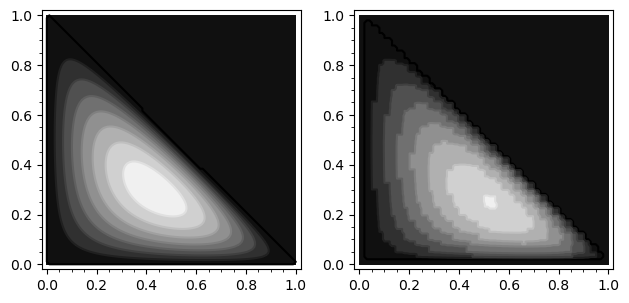

In [13]:
graphics_array([contour_plot(g,(0,1),(0,1)), contour_plot(f, (0,1), (0,1))])